# Autocorrelación Espacial Global (*Global Spatial Autocorrelation*)

**Adaptado de:** Rey, Arribas-Bel & Wolf – *Geographic Data Science with Python*, Capítulo 6.

# 1. Entendiendo la autocorrelación espacial

La noción de **autocorrelación espacial** se refiere a la existencia de una relación funcional entre lo que ocurre en un punto del espacio y lo que ocurre en otros lugares. La autocorrelación espacial examina el grado en que la **similitud en los valores** entre observaciones de un conjunto de datos está relacionada con la **similitud en las ubicaciones** de dichas observaciones. Esto difiere de la correlación tradicional entre dos variables, ya que se centra en cómo los valores en una ubicación se relacionan con los valores en otras ubicaciones geográficas.

Este concepto está relacionado con, pero es distinto de, la **autocorrelación temporal**, que conecta el valor de una variable en un momento dado con los valores de períodos anteriores. En cambio, la autocorrelación espacial conecta el valor de una variable en una ubicación dada con los valores de la **misma variable** en otras ubicaciones. Una conceptualización alternativa la entiende como el grado de información contenida en el valor de una variable en una ubicación sobre el valor de esa misma variable en otras ubicaciones.

### Aleatoriedad espacial

Para entender mejor la autocorrelación espacial, es útil considerar cómo luce su **ausencia**. Un concepto clave aquí es la **aleatoriedad espacial**: una situación en la que la ubicación de una observación no proporciona **ninguna información** sobre su valor. En otras palabras, una variable es espacialmente aleatoria si su distribución no sigue ningún patrón espacial discernible. La autocorrelación espacial puede definirse entonces como la **ausencia de aleatoriedad espacial**.

Sin embargo, esta definición es demasiado vaga para aplicaciones prácticas. La autocorrelación espacial se categoriza típicamente a lo largo de dos dimensiones principales: **signo** y **escala**.

### Autocorrelación espacial positiva

Similar a los casos tradicionales no-espaciales, la autocorrelación espacial puede adoptar dos formas principales: positiva y negativa. La **autocorrelación positiva** se relaciona con una situación donde la similitud y la cercanía geográfica van de la mano. En otras palabras, los **valores similares se ubican cerca** unos de otros, mientras que los valores diferentes tienden a estar dispersos y más lejos.

Es importante notar que el **signo de los valores no es relevante** para la presencia de autocorrelación espacial: pueden ser valores altos cerca de valores altos, o valores bajos cerca de valores bajos. Lo importante es que la relación entre cercanía y similitud estadística sea positiva.

Esto es bastante común en muchos contextos sociales. Por ejemplo, la distribución del **ingreso** o la **pobreza** en el espacio típicamente muestra valores similares ubicados cerca (áreas ricas cerca de otras áreas ricas, poblaciones pobres concentradas espacialmente).

### Autocorrelación espacial negativa

La **autocorrelación negativa** refleja una situación donde los valores similares tienden a ubicarse **lejos unos de otros**. En este caso, la similitud estadística se asocia con la distancia. Esto es menos común en las ciencias sociales, pero existe. Ejemplos incluyen fenómenos que siguen procesos de **competencia espacial** o situaciones donde la localización de instalaciones busca la mayor cobertura espacial. La distribución de supermercados de diferentes marcas o de hospitales usualmente sigue un patrón de dependencia espacial negativa.

### Global vs. Local

Entender la autocorrelación espacial también se beneficia de considerar la **escala** a la que se examina:

- **Autocorrelación global** (foco de este notebook): considera la tendencia general que sigue la distribución geográfica de los valores. Al estudiarla, es posible hacer afirmaciones sobre el **grado de agrupamiento** (*clustering*) en el conjunto de datos. ¿Siguen los valores algún patrón particular en su distribución geográfica? ¿Están los valores similares más cerca de otros valores similares de lo que esperaríamos por puro azar? Estas preguntas se relacionan con la autocorrelación espacial global.

- **Autocorrelación local**: se enfoca en desviaciones de la tendencia global a niveles mucho más focalizados que el mapa completo. Es el tema del siguiente notebook.

### Análisis Exploratorio de Datos Espaciales (ESDA)

Estos conceptos se exploran a través de herramientas conocidas colectivamente como **Análisis Exploratorio de Datos Espaciales** (ESDA, por sus siglas en inglés). Análogo a su contraparte no-espacial (EDA), el ESDA ha sido diseñado específicamente para este propósito, poniendo el **espacio y la ubicación relativa** de las observaciones al frente del análisis. El rango de métodos ESDA es amplio y abarca desde enfoques más simples como los mapas coropléticos hasta metodologías más avanzadas que incluyen **inferencia estadística** y el reconocimiento explícito de la disposición geográfica de los datos.

# 2. Ilustración empírica: el Referéndum de la UE (Brexit)

El **referéndum del Brexit** de 2016 en el Reino Unido proporciona nuestro ejemplo empírico. En este referéndum, los ciudadanos británicos votaron sobre si el Reino Unido debía abandonar la Unión Europea. Los datos combinan los resultados de la **Comisión Electoral** (porcentajes de voto a nivel de autoridad local) con los límites geográficos de los **Distritos de Autoridad Local** (LAD) proporcionados por la Oficina Nacional de Estadísticas (ONS).

La variable principal que analizaremos es `Pct_Leave`, que mide la **proporción de votos a favor de abandonar la UE** en cada autoridad local.

## 2.1 Configuración e importación de librerías

In [7]:
# Gráficos
import matplotlib.pyplot as plt
import seaborn
import splot
from splot.esda import plot_moran
import contextily

# Análisis
import geopandas
import pandas
import esda
from libpysal import weights
from numpy.random import seed

## 2.2 Carga y preparación de datos

In [15]:
# Cargar resultados del referéndum (CSV)
brexit_data_path = "datos/external/brexit/brexit_vote.csv"
ref = pandas.read_csv(brexit_data_path, index_col="Area_Code")
ref.head()

,id,Region_Code,Region,Area,Electorate,ExpectedBallots,VerifiedBallotPapers,Pct_Turnout,Votes_Cast,Valid_Votes,Remain,Leave,Rejected_Ballots,No_official_mark,Voting_for_both_answers,Writing_or_mark,Unmarked_or_void,Pct_Remain,Pct_Leave,Pct_Rejected
Area_Code,,,,,,,,,,,,,,,,,,,,
E06000031,108,E12000006,East,Peterborough,120892,87474,87469,72.35,87469,87392,34176,53216,77,0,32,7,38,39.11,60.89,0.09
E06000032,109,E12000006,East,Luton,127612,84633,84636,66.31,84616,84481,36708,47773,135,0,85,0,50,43.45,56.55,0.16
E06000033,112,E12000006,East,Southend-on-Sea,128856,93948,93939,72.90,93939,93870,39348,54522,69,0,21,0,48,41.92,58.08,0.07
E06000034,113,E12000006,East,Thurrock,109897,79969,79954,72.75,79950,79916,22151,57765,34,0,8,3,23,27.72,72.28,0.04
E06000055,110,E12000006,East,Bedford,119530,86136,86136,72.06,86135,86066,41497,44569,69,0,26,1,42,48.22,51.78,0.08


In [9]:
# Cargar límites geográficos de los distritos de autoridad local (GeoJSON)
lads = geopandas.read_file(
    "datos/external/brexit/local_authority_districts.geojson"
).set_index("lad16cd")
lads.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 391 entries, E06000001 to W06000023
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   objectid    391 non-null    int64   
 1   lad16nm     391 non-null    object  
 2   lad16nmw    22 non-null     object  
 3   bng_e       391 non-null    int64   
 4   bng_n       391 non-null    int64   
 5   long        391 non-null    float64 
 6   lat         391 non-null    float64 
 7   st_areasha  391 non-null    float64 
 8   st_lengths  391 non-null    float64 
 9   geometry    391 non-null    geometry
dtypes: float64(4), geometry(1), int64(3), object(2)
memory usage: 33.6+ KB


In [10]:
# Combinar datos electorales con geometrías
db = (
    geopandas.GeoDataFrame(
        lads.join(ref[["Pct_Leave"]]), crs=lads.crs
    )
    .to_crs(epsg=3857)[
        ["objectid", "lad16nm", "Pct_Leave", "geometry"]
    ]
    .dropna()
)
db.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 380 entries, E06000001 to W06000023
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   objectid   380 non-null    int64   
 1   lad16nm    380 non-null    object  
 2   Pct_Leave  380 non-null    float64 
 3   geometry   380 non-null    geometry
dtypes: float64(1), geometry(1), int64(1), object(1)
memory usage: 14.8+ KB


## 2.3 Mapa coroplético del % Leave

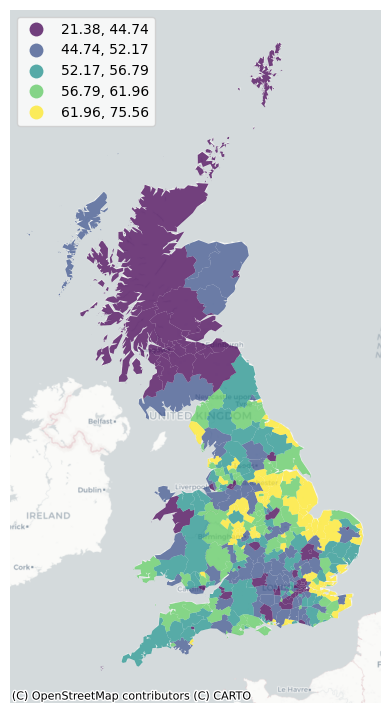

In [11]:
f, ax = plt.subplots(1, figsize=(9, 9))
db.plot(
    column="Pct_Leave",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    legend_kwds={"loc": 2},
    ax=ax,
)
contextily.add_basemap(
    ax,
    crs=db.crs,
    source=contextily.providers.CartoDB.Positron,
)
ax.set_axis_off()

El mapa anterior es una buena forma de comenzar a explorar los principales patrones espaciales en los datos. A primera vista, parece mostrar una cantidad considerable de **autocorrelación espacial positiva**: las autoridades locales con altos porcentajes de voto Leave tienden a estar junto a otras similares (véase la región este de Inglaterra), al igual que aquellas donde una proporción mucho menor votó por salir (siendo Escocia un buen ejemplo en el norte).

Los seres humanos somos **detectores de patrones extraordinarios**. A lo largo de nuestra historia como especie, la vida ha recompensado las habilidades de reconocimiento de patrones y ha castigado a quienes carecían de ellas. Esta capacidad tiende también a generar muchos **falsos positivos**: casos donde creemos ver un patrón, pero en realidad lo que observamos es en gran medida aleatorio. Esto se acentúa en el caso de los **mapas coropléticos**, donde la **forma y el tamaño** de las geometrías pueden distorsionar significativamente nuestra percepción del patrón subyacente.

Ese es exactamente el propósito de los **indicadores de autocorrelación espacial global**: aprovechar el poder de la estadística para **resumir** la distribución espacial de valores en un mapa y obtener una **cuantificación formal** de la desviación respecto a la aleatoriedad.

## 2.4 Construcción de la matriz de pesos espaciales

La última pieza que necesitamos antes de adentrarnos en la autocorrelación es la **matriz de pesos espaciales**. Como vimos en el notebook anterior, esta matriz codifica las relaciones de vecindad entre las observaciones.

Para este ejemplo usaremos una matriz de **8 vecinos más cercanos** (KNN con $k=8$). La elección de $k$ es una decisión del analista — más adelante en las preguntas de estudio exploraremos cómo distintos valores de $k$ afectan los resultados.

Además, aplicamos una **estandarización por filas** (`w.transform = "R"`). Esto significa que los pesos de cada fila se dividen por la suma de esa fila, de modo que todos los pesos de los vecinos de una observación suman 1. La consecuencia práctica es que, cuando calculemos el rezago espacial, obtendremos el **promedio ponderado** de los valores vecinos en lugar de su suma. Esta transformación es fundamental para la interpretación de los estadísticos de autocorrelación que veremos a continuación.

In [16]:
# Generar W de k-vecinos más cercanos (k=8)
w = weights.KNN.from_dataframe(db, k=8)



In [17]:
import pandas
wdf = pandas.DataFrame(*w.full())
wdf.head()

,0,1,2,3,4,5,6,7,8,9,...,370,371,372,373,374,375,376,377,378,379
E06000001,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E06000002,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E06000003,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E06000004,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E06000010,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


La matriz anterior muestra los pesos **originales** (binarios): cada vecino tiene peso **1** y los no-vecinos peso **0**. Ahora aplicamos la **estandarización por filas** (*Row-standardization*), que consiste en dividir cada peso por la suma de su fila. En PySAL, esto se hace asignando `"R"` a la propiedad `w.transform`:

| Valor | Nombre | Qué hace | Resultado |
|-------|--------|----------|----------|
| `"O"` | Original | Mantiene los pesos binarios | vecino = 1, no-vecino = 0 |
| `"R"` | Row | Divide cada peso por la suma de su fila | vecino = 1/k, no-vecino = 0 |

Como cada observación tiene exactamente 8 vecinos, cada peso pasa de `1` a `1/8 = 0.125`, y la suma de cada fila pasa a ser 1. Esta transformación es **reversible**: si luego necesitamos los pesos originales, basta con hacer `w.transform = "O"`.

¿Por qué importa? Porque al calcular el rezago espacial $y_{sl-i} = \sum_j w_{ij} \cdot y_j$, con pesos originales obtenemos la **suma** de los valores vecinos, pero con pesos estandarizados obtenemos el **promedio** — que es mucho más interpretable como "el valor típico alrededor de esta observación".

In [ ]:
# Estandarización por filas: cada peso se divide por la suma de su fila,
# de modo que los pesos de los vecinos de cada observación suman 1.
w.transform = "R"

In [19]:
wdf = pandas.DataFrame(*w.full())
wdf.head()

,0,1,2,3,4,5,6,7,8,9,...,370,371,372,373,374,375,376,377,378,379
E06000001,0.000,0.125,0.125,0.125,0.0,0.000,0.0,0.125,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E06000002,0.125,0.000,0.125,0.125,0.0,0.000,0.0,0.125,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E06000003,0.125,0.125,0.000,0.125,0.0,0.000,0.0,0.125,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E06000004,0.125,0.125,0.125,0.000,0.0,0.000,0.0,0.125,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E06000010,0.000,0.000,0.000,0.000,0.0,0.125,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 3. Autocorrelación espacial global

Los indicadores de autocorrelación espacial global resumen la distribución espacial de los valores y cuantifican las desviaciones respecto a la aleatoriedad. Estos estadísticos caracterizan el **grado de agrupamiento** (*clustering*) y proporcionan resúmenes visuales o numéricos que permiten evaluar formalmente si los patrones espaciales observados son significativos o podrían haber surgido por azar.

A continuación exploramos las herramientas principales para medir la autocorrelación espacial global, comenzando por el concepto fundamental del **rezago espacial**.

## 3.1 Rezago espacial (*Spatial Lag*)

El **operador de rezago espacial** es una de las aplicaciones más comunes y directas de las matrices de pesos espaciales en el análisis espacial. Conceptualmente, el rezago espacial captura el **comportamiento de una variable en el entorno inmediato** de cada ubicación; en ese sentido, funciona como un **suavizador local** de la variable.

**Notación matricial:**

$$Y_{sl} = W \cdot Y$$

**Notación individual:**

$$y_{sl-i} = \sum_j w_{ij} \cdot y_j$$

Donde $w_{ij}$ representa la celda en $W$ para la fila $i$ y columna $j$, capturando la relación espacial entre las observaciones $i$ y $j$. El valor $y_{sl-i}$ captura el producto de los valores y pesos de cada otra observación en el dataset. Como los **no-vecinos reciben peso cero**, $y_{sl-i}$ realmente captura el producto de valores y pesos solo para los vecinos de $i$.

El comportamiento del rezago depende del tipo de pesos utilizados:

- Con pesos **binarios**, el rezago espacial equivale a la **suma** de los valores de los vecinos de $i$ (útil en estudios de potencial de mercado).
- Con pesos **estandarizados por fila** (una transformación común donde $w_{ij}$ queda acotado entre 0 y 1), el rezago se convierte en un **promedio local** — el valor promedio de $Y$ en el vecindario de cada observación $i$. Este último significado es el que permite el análisis de autocorrelación espacial que discutimos a continuación.

La naturaleza suavizadora del rezago se puede apreciar visualmente: las diferencias abruptas entre vecinos inmediatos en un mapa se atenúan en un mapa de rezago espacial. Como se ha descubierto a lo largo del trabajo en análisis espacial, el rezago espacial es un elemento clave en muchas técnicas y tiene soporte completo en PySAL.

### ¿Qué es el rezago espacial en términos simples?

El rezago espacial de una observación es simplemente el **promedio de los valores de sus vecinos**. Te permite responder la pregunta: *¿cómo es el entorno de esta observación?*

Tomemos dos ejemplos concretos de nuestros datos:

- **Liverpool** votó ~42% Leave. Pero está en el norte de Inglaterra, rodeada de zonas con alto voto Leave. Su rezago espacial (~57%) refleja ese entorno: Liverpool es **diferente a sus vecinos**.
- **Midlothian** (Escocia) votó ~38% Leave. Sus vecinos escoceses también votaron bajo, así que su rezago (~28%) es similar. Midlothian se **parece a su vecindario**.

A pesar de tener porcentajes individuales similares (~42% y ~38%), sus contextos geográficos producen rezagos muy distintos (~57% vs ~28%). Esa es la gracia del rezago: no solo importa el valor en sí, sino **dónde está ubicado**.

Veamos estos dos casos en el mapa, destacando cada observación y sus 8 vecinos más cercanos:

In [ ]:
# Primero calculamos el rezago para poder mostrar los valores
db["Pct_Leave_lag"] = weights.spatial_lag.lag_spatial(w, db["Pct_Leave"])

f, axs = plt.subplots(1, 2, figsize=(16, 7))

examples = {
    "Liverpool (E08000012)": "E08000012",
    "Midlothian (S12000019)": "S12000019",
}

for ax, (title, code) in zip(axs, examples.items()):
    # Mapa base en gris claro
    db.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.3)

    # Obtener vecinos (w.neighbors usa el mismo índice que el dataframe)
    neighbor_codes = w.neighbors[code]
    neighbors = db.loc[neighbor_codes]

    # Colorear vecinos en azul
    neighbors.plot(ax=ax, color="steelblue", edgecolor="white", linewidth=0.5, alpha=0.7)

    # Colorear la observación principal en rojo
    db.loc[[code]].plot(ax=ax, color="red", edgecolor="black", linewidth=1.5)

    # Título con valores
    obs_val = db.loc[code, "Pct_Leave"]
    lag_val = db.loc[code, "Pct_Leave_lag"]
    ax.set_title(f"{title}\nValor: {obs_val:.1f}% | Rezago (promedio vecinos): {lag_val:.1f}%")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

En rojo se muestra la observación y en azul sus 8 vecinos más cercanos. El rezago espacial es simplemente el promedio del % Leave de las zonas azules.

Formalmente, esto se expresa como:

$$y_{sl-i} = \sum_j w_{ij} \cdot y_j$$

Donde $w_{ij} = 0.125$ (es decir $1/8$) para cada vecino, y $0$ para el resto. La suma de los productos es equivalente a calcular el promedio.

In [ ]:
# Visualización lado a lado: variable original vs. rezago espacial
f, axs = plt.subplots(1, 2, figsize=(12, 6))
ax1, ax2 = axs

db.plot(
    column="Pct_Leave",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    ax=ax1,
)
ax1.set_axis_off()
ax1.set_title("% Leave")
contextily.add_basemap(
    ax1,
    crs=db.crs,
    source=contextily.providers.CartoDB.Positron,
)

db.plot(
    column="Pct_Leave_lag",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    ax=ax2,
)
ax2.set_axis_off()
ax2.set_title("% Leave - Rezago Espacial")
contextily.add_basemap(
    ax2,
    crs=db.crs,
    source=contextily.providers.CartoDB.Positron,
)

plt.show()

El rezago espacial suaviza las diferencias abruptas del mapa original. Las zonas atípicas (como Liverpool, aislada en medio de vecinos con alto % Leave) se atenúan en el mapa de la derecha.

## 3.2 Caso binario: *Join Counts* (conteo de uniones)

El rezago espacial juega un papel importante en la cuantificación de la autocorrelación espacial, ya que permite relacionar el comportamiento de una variable en una ubicación dada con su patrón en el vecindario inmediato. Las medidas de autocorrelación espacial global usan cada observación para construir medidas generales sobre la **tendencia predominante** en un conjunto de datos.

La primera exploración de estas medidas considera un caso simplificado: **valores binarios**. Esto ocurre cuando la variable de interés solo toma dos valores. En este contexto, nos interesa saber si una observación dada está rodeada por otras de la **misma categoría**. Por ejemplo, queremos evaluar en qué medida las autoridades locales que votaron a favor de Leave tienden a estar rodeadas por otras que también votaron Leave.

Visualmente, al examinar un mapa binario podemos notar lo que parece ser clara autocorrelación espacial positiva: en general, hay pocos casos visibles donde una observación está rodeada por otras de la categoría opuesta. Para explorar formalmente esta evaluación inicial, usamos lo que se conoce como **estadístico de conteo de uniones** (*Join Count*).

Imaginemos un tablero con cuadrados de dos colores: **verde** (G, valor 0) y **amarillo** (A, valor 1). La idea del estadístico es contar las ocurrencias de uniones verde-verde (GG), amarillo-amarillo (AA), o verde-amarillo (GA) entre pares vecinos en el mapa:

| Tipo de unión | Descripción | Autocorrelación |
|---------------|-------------|------------------|
| GG (verde-verde) | Vecinos con el mismo valor (0-0) | Positiva |
| AA (amarillo-amarillo) | Vecinos con el mismo valor (1-1) | Positiva |
| GA (verde-amarillo) | Vecinos con distinto valor (0-1) | Negativa |

La intuición del estadístico es proporcionar una **línea base** de cuántas uniones GG, AA y GA esperaríamos bajo el caso de **completa aleatoriedad espacial**, y comparar esto con los conteos observados en el dataset. Una situación donde observamos **más GG/AA de lo esperado** y **menos GA de lo esperado** sugeriría autocorrelación espacial positiva; mientras que lo opuesto — más GA que GG/AA — apuntaría hacia autocorrelación espacial negativa.

In [ ]:
# Crear variable binaria: 1 si el % Leave > 50
db["Leave"] = (db["Pct_Leave"] > 50).astype(int)
db[["Pct_Leave", "Leave"]].tail()

In [ ]:
# Mapa de la variable binaria
f, ax = plt.subplots(1, figsize=(9, 9))
db.plot(
    ax=ax,
    column="Leave",
    categorical=True,
    legend=True,
    edgecolor="0.5",
    linewidth=0.25,
    cmap="Set3",
    figsize=(9, 9),
)
ax.set_axis_off()
ax.set_title("Mayoría Leave")
plt.axis("equal")
plt.show()

El estadístico de Join Counts requiere pesos **binarios** (originales), ya que los pesos espaciales solo se usan aquí para delimitar **quién es vecino y quién no** — no necesitamos promedios ponderados. Por eso cambiamos la transformación de la matriz de `"R"` (estandarizada por filas) a `"O"` (original/binaria):

In [ ]:
# Join Counts requiere pesos binarios (no estandarizados)
w.transform = "O"

In [ ]:
# Calcular Join Counts
seed(1234)
jc = esda.join_counts.Join_Counts(db["Leave"], w)

In [ ]:
# Resultados: conteo de uniones observadas
print(f"Uniones GG (0-0): {jc.bb}")
print(f"Uniones AA (1-1): {jc.ww}")
print(f"Uniones GA (0-1): {jc.bw}")
print(f"Total de uniones: {jc.J}")
print(f"Verificación: {jc.bb + jc.ww + jc.bw}")

In [ ]:
# Valores esperados bajo aleatoriedad espacial
print(f"Uniones GG esperadas: {jc.mean_bb:.1f}")
print(f"Uniones GA esperadas: {jc.mean_bw:.1f}")

In [ ]:
# Pseudo p-valores (prueba de significancia mediante permutaciones)
print(f"P-valor para uniones misma categoría (GG): {jc.p_sim_bb:.4f}")
print(f"P-valor para uniones distinta categoría (GA): {jc.p_sim_bw:.4f}")

PySAL realiza **999 permutaciones espaciales** bajo la hipótesis nula de aleatoriedad, generando pseudo p-valores. En cada permutación, los valores se redistribuyen aleatoriamente entre las ubicaciones, manteniendo los mismos valores pero cambiando su disposición geográfica. Luego se calcula el estadístico para cada mapa aleatorio, construyendo una **distribución de referencia** bajo aleatoriedad espacial.

Los resultados demuestran una fuerte **autocorrelación espacial positiva**: ocurren significativamente más uniones de misma categoría de lo esperado (`p_sim_bb` muy pequeño), y significativamente menos uniones de categoría opuesta (`p_sim_bw` también muy pequeño). Esto confirma que el patrón observado — donde las regiones Leave tienden a estar junto a otras regiones Leave, y las Remain junto a otras Remain — es extremadamente improbable que haya surgido por azar.

## 3.3 Caso continuo: Gráfico de Moran e I de Moran

Una vez construida la intuición sobre cómo se evalúa formalmente la autocorrelación espacial en el caso binario, pasamos a situaciones donde la variable de interés no solo toma dos valores, sino que es **continua**. Probablemente el estadístico más utilizado en este contexto es el **I de Moran**, que puede escribirse como:

$$I = \frac{n}{\sum_i \sum_j w_{ij}} \cdot \frac{\sum_i \sum_j w_{ij} \, z_i \, z_j}{\sum_i z_i^2}$$

Donde:
- $n$ = número de observaciones
- $z_i = y_i - \bar{y}$ es el valor estandarizado de la variable de interés en la ubicación $i$
- $w_{ij}$ es la celda correspondiente a la fila $i$ y columna $j$ de la matriz de pesos espaciales $W$

### Gráfico de Moran (*Moran Plot*)

Para entender la intuición detrás del I de Moran matemáticamente, es útil comenzar con una **interpretación gráfica**: el **Gráfico de Moran**. Este es una forma de visualizar un conjunto de datos espaciales para explorar la naturaleza y la fuerza de la autocorrelación espacial. Es esencialmente un **diagrama de dispersión** tradicional en el que la variable de interés se muestra contra su **rezago espacial**. Para poder interpretar los valores como por encima o por debajo de la media, la variable de interés se estandariza restándole su media.

El Gráfico de Moran muestra la relación entre la variable estandarizada en una ubicación y su rezago espacial, que — dado que la $W$ utilizada está estandarizada por filas — puede interpretarse como el **valor estandarizado promedio en el vecindario** de cada observación. Para guiar la interpretación del gráfico, se incluye típicamente un **ajuste lineal**, que representa la mejor línea recta que describe la relación entre las dos variables. La **pendiente de esta línea** corresponde al valor del I de Moran.

In [ ]:
# Estandarizar la variable (restar la media)
db["Pct_Leave_std"] = db["Pct_Leave"] - db["Pct_Leave"].mean()

# Calcular el rezago espacial de la variable estandarizada
db["Pct_Leave_lag_std"] = weights.lag_spatial(
    w, db["Pct_Leave_std"]
)

In [ ]:
# Gráfico de Moran
f, ax = plt.subplots(1, figsize=(6, 6))
seaborn.regplot(
    x="Pct_Leave_std",
    y="Pct_Leave_lag_std",
    ci=None,
    data=db,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Gráfico de Moran - % Leave")
plt.show()

El gráfico muestra una **relación positiva** entre el porcentaje estandarizado de Leave y su rezago espacial (interpretado como el promedio del vecindario gracias a la estandarización por filas). El ajuste lineal incluido representa la mejor línea recta que captura esta relación, o en otras palabras, la mejor forma de representar la relación entre las dos variables como una línea recta.

Cuando el gráfico muestra una relación positiva, esto indica la presencia de **autocorrelación espacial positiva**: valores similares tienden a ubicarse cerca unos de otros. Esto significa que la tendencia general es que los valores altos estén cerca de otros valores altos, y los valores bajos rodeados de otros valores bajos. Esto **no significa** que este sea el único caso en el dataset: por supuesto puede haber situaciones particulares donde valores altos están rodeados de bajos, y viceversa. Pero sí significa que, si tuviéramos que resumir el patrón principal de los datos en términos de cuán agrupados están los valores similares, la mejor forma sería decir que están positivamente correlacionados y, por ende, **agrupados en el espacio**.

Los cuatro cuadrantes del gráfico tienen interpretaciones específicas:

| Cuadrante | Valor propio | Valor vecinos | Interpretación |
|-----------|-------------|---------------|----------------|
| Superior derecho (I) | Alto (+) | Alto (+) | Cluster de valores altos (HH) |
| Inferior izquierdo (III) | Bajo (-) | Bajo (-) | Cluster de valores bajos (LL) |
| Superior izquierdo (II) | Bajo (-) | Alto (+) | Atípico espacial (LH) |
| Inferior derecho (IV) | Alto (+) | Bajo (-) | Atípico espacial (HL) |

El Gráfico de Moran es una herramienta excelente para explorar los datos y tener una buena noción de cuánto se agrupan los valores en el espacio. Sin embargo, al ser un dispositivo gráfico, a veces es difícil condensar sus insights de forma más concisa. Para estos casos, necesitamos una **medida estadística** que resuma la figura. El **I de Moran** está diseñado exactamente para esto.

De la misma manera que la **media** resume un elemento crucial de la distribución de valores en un contexto no-espacial, así lo hace el I de Moran para un dataset espacial. Podemos pensar en la media como un valor numérico único que resume un histograma. De forma análoga, el I de Moran captura gran parte de la esencia del Gráfico de Moran. De hecho, existe una conexión directa entre ambos: el valor del **I de Moran corresponde con la pendiente del ajuste lineal** superpuesto sobre el Gráfico de Moran.

In [ ]:
# Volvemos a estandarización por filas (la habíamos cambiado a "O" para Join Counts)
w.transform = "R"

# Calcular I de Moran formalmente
moran = esda.moran.Moran(db["Pct_Leave"], w)

In [ ]:
# Valor del estadístico
print(f"I de Moran: {moran.I:.4f}")

In [ ]:
# Pseudo p-valor (significancia estadística)
print(f"Pseudo p-valor: {moran.p_sim:.4f}")

El I de Moran se relaciona con la **inferencia estadística**: ¿podría el patrón observado en el mapa (y medido por el I de Moran) haber surgido puramente por azar? Si consideráramos la misma variable pero redistribuyéramos sus ubicaciones aleatoriamente, ¿obtendríamos un mapa con características similares?

Para responder estas preguntas, se realizan **simulaciones** y se devuelve una medida de certeza sobre cuán probable es obtener un patrón como el observado bajo un proceso espacialmente aleatorio. Esto se resume en el atributo `p_sim`.

El valor se calcula como un **p-valor empírico** que representa la proporción de realizaciones en la simulación bajo aleatoriedad espacial que son más extremas que el valor observado. Un p-valor suficientemente pequeño asociado al I de Moran permite **rechazar la hipótesis** de que el mapa es aleatorio. En otras palabras, podemos concluir que el mapa muestra más patrón espacial del que esperaríamos si los valores hubieran sido asignados aleatoriamente a las ubicaciones.

La simulación genera un gran número de mapas con los mismos valores pero asignados aleatoriamente sobre el espacio, y calcula el I de Moran para cada uno. Si solo un **pequeño porcentaje** de estos mapas aleatorios muestra un valor absoluto mayor al obtenido con los datos observados, esto indica que la disposición espacial particular de los valores está **más concentrada** de lo que estaría si las proporciones de voto se hubieran redistribuido aleatoriamente por el mapa.

In [ ]:
# Visualización combinada con splot
plot_moran(moran);

El panel **izquierdo** muestra la distribución empírica (gris) del I de Moran calculado para 999 mapas aleatorios simulados. La marca azul señala la media; la marca roja indica el I de Moran **observado**. El valor observado se ubica sustancialmente por encima de la distribución de aleatoriedad. El panel **derecho** replica el gráfico de dispersión de Moran.

## 3.4 Otros índices globales

Aunque el I de Moran domina las aplicaciones, existen medidas alternativas que capturan diferentes aspectos de la autocorrelación espacial.

### C de Geary

La **razón de contigüidad** $c$ de Robert Geary es otra medida de autocorrelación espacial global, expresada como:

$$C = \frac{(n-1)}{2 \sum_i \sum_j w_{ij}} \cdot \frac{\sum_i \sum_j w_{ij} (y_i - y_j)^2}{\sum_i (y_i - \bar{y})^2}$$

Donde $n$ es el número de observaciones, $w_{ij}$ es la celda en una matriz binaria $W$ que expresa si $i$ y $j$ son vecinos ($w_{ij}=1$) o no ($w_{ij}=0$), $y_i$ es la $i$-ésima observación de la variable de interés, y $\bar{y}$ es su media muestral.

Al comparar con el I de Moran, resulta evidente que ambas medidas comparan la relación de $Y$ dentro del **vecindario local** de cada observación con la relación sobre la **muestra completa**. Sin embargo, existen diferencias sutiles pero importantes:

- El **I de Moran** utiliza **productos cruzados** de valores estandarizados ($z_i \cdot z_j$)
- La **C de Geary** utiliza **diferencias al cuadrado** de valores no estandarizados ($(y_i - y_j)^2$)

Esta diferencia hace que la C de Geary sea más sensible a las diferencias **locales** entre vecinos, mientras que el I de Moran captura mejor la tendencia **global**.

Valores de referencia:
- $C \approx 1$: aleatoriedad espacial
- $C < 1$: autocorrelación positiva (los vecinos son similares)
- $C > 1$: autocorrelación negativa (los vecinos son disímiles)

La inferencia se realiza de manera similar al I de Moran: se ejecuta una simulación que permite construir una distribución empírica del estadístico bajo la hipótesis nula de aleatoriedad espacial, y luego se compara con el estadístico obtenido usando la distribución geográfica observada de los datos.

In [ ]:
geary = esda.geary.Geary(db["Pct_Leave"], w)

print(f"C de Geary: {geary.C:.4f}")
print(f"Pseudo p-valor: {geary.p_sim:.4f}")

La C de Geary confirma los resultados del I de Moran: hay una **desviación significativa de la aleatoriedad espacial**, apoyando la conclusión de autocorrelación espacial positiva en la distribución del voto Leave. El estadístico observado difiere significativamente de lo que se esperaría bajo aleatoriedad, lo que refuerza la conclusión de que los patrones de voto están espacialmente agrupados.

### G de Getis y Ord

Propuesto originalmente como una versión global de una familia de estadísticos de autocorrelación espacial basada en **distancia**, el estadístico G fue concebido para puntos y por tanto usa una $W$ de distancia, aunque también puede aplicarse a datos poligonales si se puede construir una matriz de pesos espaciales binaria. Además, está diseñado para el estudio de **variables positivas con un origen natural**. La G puede expresarse como:

$$G(d) = \frac{\sum_i \sum_j w_{ij}(d) \, y_i \, y_j}{\sum_i \sum_j y_i \, y_j}$$

Donde $w_{ij}(d)$ es el peso binario asignado según un criterio de **banda de distancia** entre las observaciones $i$ y $j$.

G fue propuesto originalmente como una medida de **concentración** más que de autocorrelación espacial propiamente dicha. Como tal, es particularmente adecuado para probar en qué medida valores similares (ya sean altos o bajos) tienden a **co-localizarse**. En otras palabras, G es un estadístico de **autocorrelación espacial positiva**.

Este suele ser el interés en la mayoría de las aplicaciones de Ciencia de Datos Geográficos. Sin embargo, es importante notar que, como G puede entenderse como una medida de la intensidad con la que $Y$ está concentrada, el estadístico **no es capaz de detectar** casos de autocorrelación espacial **negativa**. Esta es una diferencia fundamental respecto al I de Moran y la C de Geary, que sí pueden identificar ambos tipos.

De manera similar a otras medidas de autocorrelación espacial global, la inferencia se lleva a cabo mediante **simulaciones computacionales** que replican múltiples instancias de aleatoriedad espacial usando los valores de la variable de interés, pero redistribuyendo sus ubicaciones.

In [ ]:
# Reproyectar a OSGB (EPSG:27700) para distancias en metros
db_osgb = db.to_crs(epsg=27700)

# Calcular la distancia mínima umbral para que todos tengan al menos un vecino
pts = db_osgb.centroid
xys = pandas.DataFrame({"X": pts.x, "Y": pts.y})
min_thr = weights.util.min_threshold_distance(xys)
print(f"Distancia umbral mínima: {min_thr:.1f} metros")

In [ ]:
# Crear pesos de banda de distancia
w_db = weights.DistanceBand.from_dataframe(db_osgb, min_thr)

In [ ]:
# Calcular G de Getis y Ord
gao = esda.getisord.G(db["Pct_Leave"].values, w_db)

print(
    "Getis & Ord G: %.3f | Pseudo P-valor: %.3f" % (gao.G, gao.p_sim)
)

El pseudo p-valor sugiere una **desviación significativa** de la hipótesis de no-concentración, indicando patrones claros de concentración en la distribución espacial del voto Leave. Esto es consistente con los resultados obtenidos mediante el I de Moran y la C de Geary, proporcionando evidencia adicional desde una perspectiva diferente (concentración vs. correlación) de que el patrón de voto no es aleatorio en el espacio.

# 4. Resumen

| Estadístico | Tipo de variable | Qué mide | Valor de referencia |
|-------------|-----------------|----------|--------------------|
| Join Counts | Binaria | Agrupación de categorías | Esperado bajo aleatoriedad |
| I de Moran | Continua | Correlación espacial global | $I = 0$ (sin autocorrelación) |
| C de Geary | Continua | Similitud entre vecinos | $C = 1$ (aleatoriedad) |
| G de Getis-Ord | Continua (positiva) | Concentración de valores | Esperado bajo aleatoriedad |

Los tres estadísticos para variables continuas confirman la presencia de **autocorrelación espacial positiva significativa** en la distribución del voto a favor de abandonar la UE en el Reino Unido.

# 5. Preguntas de estudio

1. Vuelve a la tabla original `ref` y extrae la variable `Pct_Rejected` (votos rechazados):
   - a) Crea un mapa coroplético mostrando la distribución espacial de `Pct_Rejected`.
   - b) Construye una matriz de pesos de 8 vecinos más cercanos.
   - c) Crea un gráfico de Moran relacionando `Pct_Rejected` con su rezago espacial.
   - d) Calcula el I de Moran para `Pct_Rejected`.
   - e) Interpreta los resultados. ¿Qué aprendemos sobre la geografía del rechazo de votos?

2. A veces los referéndums requieren más del 50% para hacer efectivo el cambio. Imaginemos que el Brexit requería un 60%:
   - a) Usa `Pct_Leave` para crear una variable binaria que tome valor 1 si el porcentaje es mayor a 60, 0 en caso contrario.
   - b) Crea un mapa coroplético con la nueva variable. ¿Hay diferencias en el patrón geográfico?
   - c) Recalcula el estadístico Join Counts. ¿Qué puedes concluir? ¿Hay cambios notables?

3. Explora el efecto de diferentes matrices de pesos:
   - a) Crea dos matrices KNN adicionales: una con 4 vecinos (`wk4`) y otra con 12 (`wk12`).
   - b) Crea mapas del rezago espacial de `Pct_Leave` con cada nueva matriz. ¿Cómo difieren? ¿Por qué?
   - c) Genera gráficos de Moran con `wk4` y `wk12`. ¿Difieren del creado anteriormente?
   - d) Calcula el I de Moran con todas las matrices y compara resultados.

4. Con la misma matriz de pesos, calcula Moran, Geary y Getis-Ord para `Pct_Rejected`. ¿Llegas a conclusiones sustancialmente diferentes con cada estadístico? De ser así, ¿por qué?

5. A partir de los resultados de la pregunta 3, ¿puedes generalizar el efecto de un mayor número de vecinos en la matriz de pesos al explorar la autocorrelación espacial global?

6. ¿Es posible encontrar casos en que el I de Moran y la G de Getis-Ord estén en desacuerdo sustancial? ¿Qué podría provocar ese resultado? ¿Qué implica para el uso e interpretación de ambos estadísticos?

7. Usando pesos de k-vecinos más cercanos, ¿puedes encontrar el valor de k donde el I de Moran es mayor? Haz un gráfico de I de Moran vs. k.

8. Como en la pregunta anterior, ¿a qué valor de k la C de Geary es mayor?